In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from miss_alignment.data.shift_generation import JitterGenerator, OutlierGenerator, TrajectoryGenerator, FractureGenerator

sns.set(context='talk', style='ticks')

In [2]:
import torch
from pathlib import Path
from miss_alignment.data.io import TiltSeriesData
from miss_alignment.data.shift_generation import project_shifts_3d_to_2d
from torch_affine_utils.transforms_3d import Ry, Rz
from warpylib.tilt_series.reconstruct_volume import preprocess_tilt_data

# Load tilt-series data
xml_path = Path("/home/marten/data/download/shrec_zenodo/ground_truth/model_1.xml") 
tilt_series_data = TiltSeriesData(xml_metadata_path=xml_path)
tilt_series, images, pixel_size = tilt_series_data.load_metadata_and_stack(downsample=1)
tilt_series.volume_dimensions_physical = torch.tensor((512 * 10, 512 * 10, 180 * 10))
tilt_series.image_dimensions_physical = torch.tensor((512 * 10, 512 * 10))
tilt_series.size_rounding_factors = torch.tensor([1.,] * 3)


# Move to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
tilt_series = tilt_series.to(device)
images = images.to(device)

In [10]:
import torch
import math
from scipy.ndimage import rotate as scipy_rotate
from torch_fourier_shift import fourier_shift_image_2d

# Generate a 3D sphere as a simple point feature
def generate_sphere(size=64, radius=8):
    """Generate a 3D volume containing a sphere at the center."""
    coords = torch.arange(size, dtype=torch.float32) - (size - 1) / 2
    z, y, x = torch.meshgrid(coords, coords, coords, indexing='ij')
    distance = torch.sqrt(x**2 + y**2 + z**2) / radius
    distance[distance <= 1] = 1
    sigma = 1.0 / radius
    sphere = torch.exp(-1 * ((distance - 1) / sigma) ** 2)
    sphere[sphere <= math.exp(-(2**2) / 2.0)] = 0
    return sphere

# Generate projections by rotating and projecting the sphere
def generate_tilt_projections(volume, tilt_angles_deg, image_shifts_px, target_size=512):
    """
    Rotate a 3D volume according to tilt angles and project to create 2D images.
    
    Args:
        volume: 3D torch tensor containing the feature
        tilt_angles_deg: array of tilt angles in degrees
        target_size: size to pad the projections to (square images)
    
    Returns:
        Padded projections as torch tensor with shape (n_tilts, target_size, target_size)
    """
    projections = []
    volume_np = volume.cpu().numpy()
    
    for angle in tilt_angles_deg:
        # Rotate around Y-axis (corresponds to tilt geometry)
        # axes=(0, 2) means rotate in the ZX plane
        rotated = scipy_rotate(volume_np, angle, axes=(0, 2), reshape=False, order=1)
        
        # Project along Y-axis (sum)
        projection = rotated.sum(axis=2)
        
        # Pad to target size
        current_size = projection.shape[0]
        pad_total = target_size - current_size
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        
        padded = np.pad(projection, 
                       ((pad_left, pad_right), (pad_left, pad_right)),
                       mode='constant', constant_values=0)
        projections.append(padded)

    projections = torch.from_numpy(np.stack(projections)).float()
    projections = fourier_shift_image_2d(projections, image_shifts_px)
    return projections

# Setup device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Generate sphere and projections
print("Generating 3D sphere...")
sphere_volume = generate_sphere(size=64, radius=8)

# Generate projections for 61 tilt angles from -60 to 60 degrees
tilt_angles_sim = tilt_series.angles
shifts_sim = (tilt_series.tilt_axis_offset_y, tilt_series.tilt_axis_offset_x)
shifts_sim = torch.stack(shifts_sim, dim=1)
print("Creating tilt projections...")
simulated_images = generate_tilt_projections(
    sphere_volume, 
    tilt_angles_sim.cpu(), 
    shifts_sim.cpu() / pixel_size,
    target_size=512
)
# invert the contrast
simulated_images *= -1.
simulated_images = simulated_images.to(device)

print(f"Created {len(simulated_images)} projections of size {simulated_images.shape[1]}x{simulated_images.shape[2]}")

Generating 3D sphere...
Creating tilt projections...
Created 61 projections of size 512x512


## Reconstructions with Different Shift Types

In this section, we load a tilt-series and create reconstructions at a specific 3D position with different types of shifts applied.

In [11]:
# Preprocess images
patch_size = 96
images = preprocess_tilt_data(
    tilt_data=images,
    normalize=True,
    invert=False,
    subvolume_size=patch_size,
)

# preprocess the simulated images of the sphere
simulated_images = preprocess_tilt_data(
    tilt_data=simulated_images,
    normalize=True,
    invert=False,
    subvolume_size=patch_size,
)

# Select a 3D position for reconstruction (center of volume by default)
x_dim, y_dim, z_dim = tilt_series.volume_dimensions_physical
reconstruction_location = torch.tensor([[x_dim/2, y_dim/2, z_dim/2]], device=device)

print(f"Loaded tilt-series with {len(tilt_series.angles)} images")
print(f"Pixel size: {pixel_size:.2f} Å")
print(f"Volume dimensions: {x_dim:.0f} x {y_dim:.0f} x {z_dim:.0f} Å")
print(f"Reconstruction location: {reconstruction_location[0].cpu().numpy()}")

Loaded tilt-series with 61 images
Pixel size: 10.00 Å
Volume dimensions: 5120 x 5120 x 1800 Å
Reconstruction location: [2560. 2560.  900.]


In [12]:
# Setup for applying shifts
n_tilts = len(tilt_series.angles)

# Calculate projection matrices for 3D to 2D shift projection
r0 = Ry(-tilt_series.angles, zyx=True)
r1 = Rz(tilt_series.tilt_axis_angles, zyx=True)
rotation_matrices = r1 @ r0
projection_matrices = rotation_matrices[..., 1:3, :3]

# Store original alignment parameters
original_offset_x = tilt_series.tilt_axis_offset_x.clone()
original_offset_y = tilt_series.tilt_axis_offset_y.clone()

In [13]:
# Generate all shifts upfront for better control
# You can modify these generators or add random seeds for reproducibility

# Create shift generators
jitter_generator = JitterGenerator(jitter_max_std=2.0)
trajectory_generator = TrajectoryGenerator(trajectory_max_shift=10.0)
outlier_generator = OutlierGenerator(outlier_max_shift=20)
fracture_generator = FractureGenerator(fracture_max_shift=20)

# Generate 3D shifts for each type
shifts_dict = {}
shifts_dict['No shifts'] = None
shifts_dict['Jitter'] = project_shifts_3d_to_2d(jitter_generator(n_tilts, device), projection_matrices) * pixel_size
shifts_dict['Jitter'][:, 0] = .0
shifts_dict['Trajectory'] = project_shifts_3d_to_2d(trajectory_generator(n_tilts, device), projection_matrices) * pixel_size
shifts_dict['Trajectory'][:, 0] = .0
shifts_dict['Outliers'] = project_shifts_3d_to_2d(outlier_generator(n_tilts, device), projection_matrices) * pixel_size
shifts_dict['Outliers'][:, 0] = .0
shifts_dict['Fractures'] = project_shifts_3d_to_2d(fracture_generator(n_tilts, device), projection_matrices) * pixel_size
shifts_dict['Fractures'][:, 0] = .0

# Create combined shifts by summing all individual shift types
shifts_dict['Combined'] = (
    shifts_dict['Jitter'] +
    shifts_dict['Trajectory'] +
    shifts_dict['Outliers'] +
    shifts_dict['Fractures']
)

print("Generated shifts for all types:")
for shift_type, shifts in shifts_dict.items():
    if shifts is not None:
        max_shift = shifts[:, 1].abs().max().item()
        print(f"  {shift_type}: max Z-shift = {max_shift:.2f} Å")
    else:
        print(f"  {shift_type}: no shifts applied")

RuntimeError: The size of tensor a (3) must match the size of tensor b (2) at non-singleton dimension 1

In [65]:
from collections import defaultdict
# Perform reconstructions using the pre-generated shifts
reconstructions = defaultdict(list)

def apply_shifts_and_reconstruct(shifts_angstrom, label, images):
    """Apply pre-generated shifts and perform reconstruction."""
    # Reset to original alignment
    tilt_series.tilt_axis_offset_x = original_offset_x.clone()
    tilt_series.tilt_axis_offset_y = original_offset_y.clone()
    
    if shifts is not None:
        tilt_series.tilt_axis_offset_y += shifts_angstrom[:, 0]
        tilt_series.tilt_axis_offset_x += shifts_angstrom[:, 1]
    
    # Perform reconstruction
    reconstruction = tilt_series.reconstruct_subvolumes_single(
        tilt_data=images,
        coords=reconstruction_location,
        pixel_size=pixel_size,
        size=patch_size,
        apply_ctf=False,
        angles=torch.tensor([0.0, 0.0, 0.0], device=device),
        oversampling=2.0,
    ).squeeze()
    
    print(f"Completed reconstruction: {label}")
    return reconstruction.cpu()

# Perform reconstructions for all shift types
for shift_type, shifts in shifts_dict.items():
    for i, image_set in ((10, images), (48, simulated_images)):
        reconstructions[shift_type].append(apply_shifts_and_reconstruct(shifts, shift_type, image_set)[:, i])

# Reset to original alignment
tilt_series.tilt_axis_offset_x = original_offset_x
tilt_series.tilt_axis_offset_y = original_offset_y

Completed reconstruction: No shifts
Completed reconstruction: No shifts
Completed reconstruction: Jitter
Completed reconstruction: Jitter
Completed reconstruction: Trajectory
Completed reconstruction: Trajectory
Completed reconstruction: Outliers
Completed reconstruction: Outliers
Completed reconstruction: Fractures
Completed reconstruction: Fractures
Completed reconstruction: Combined
Completed reconstruction: Combined


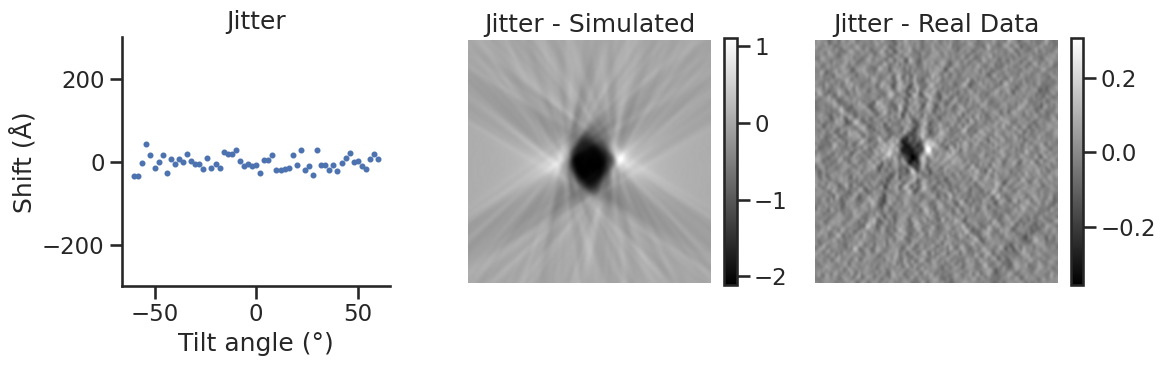

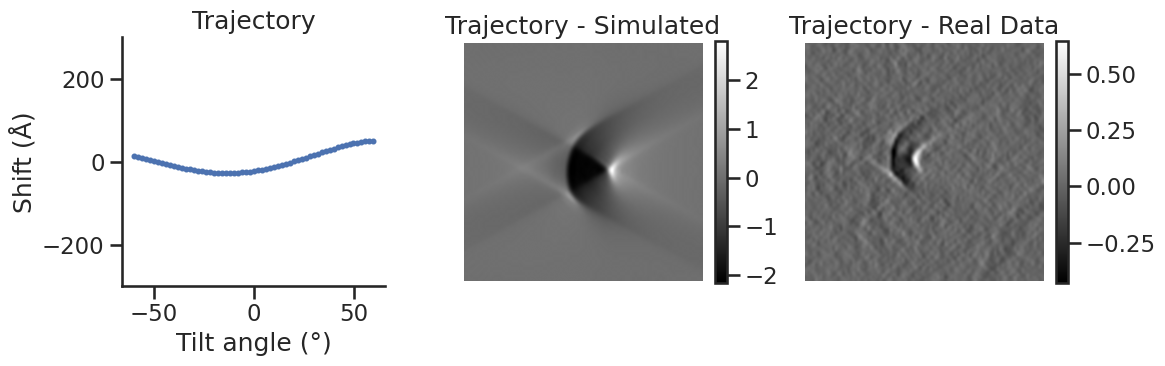

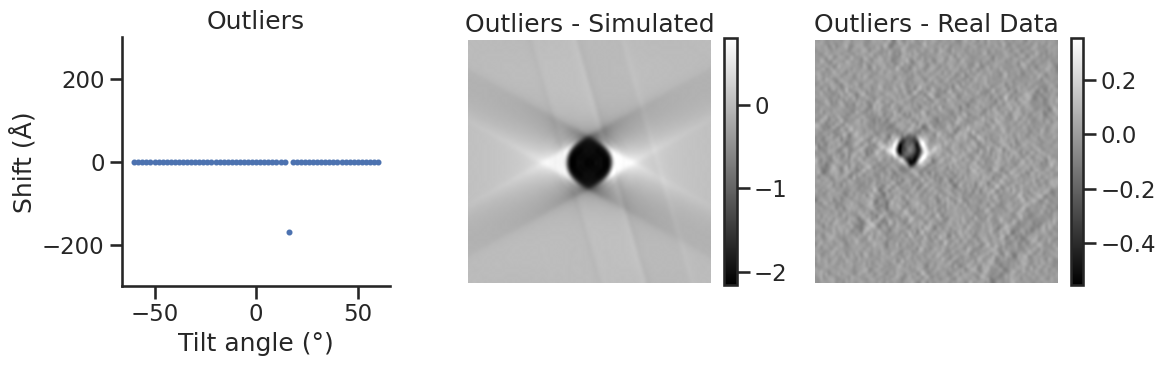

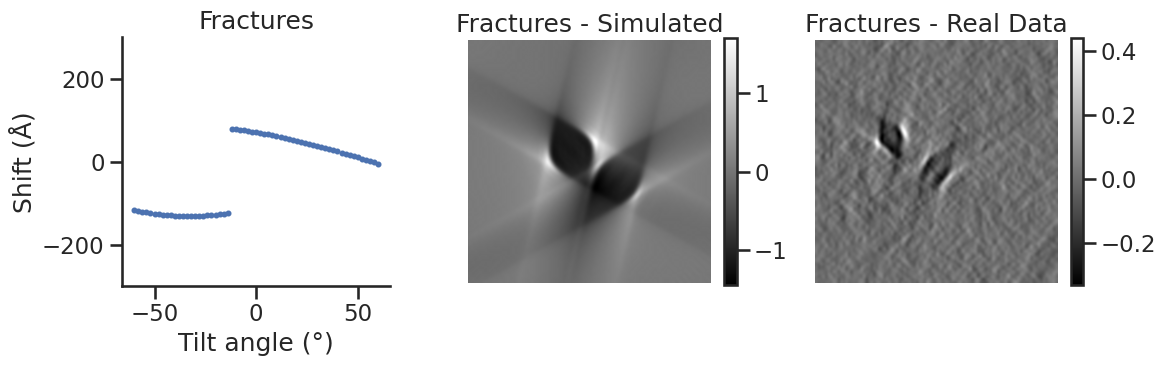

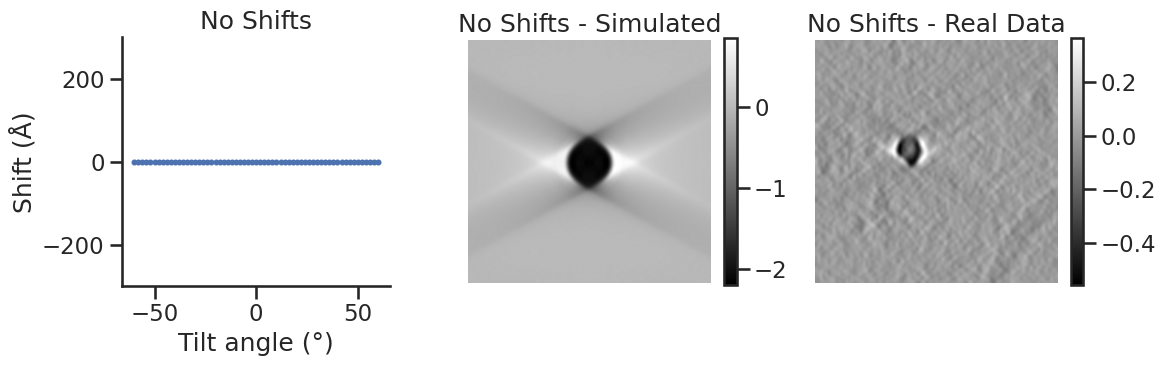

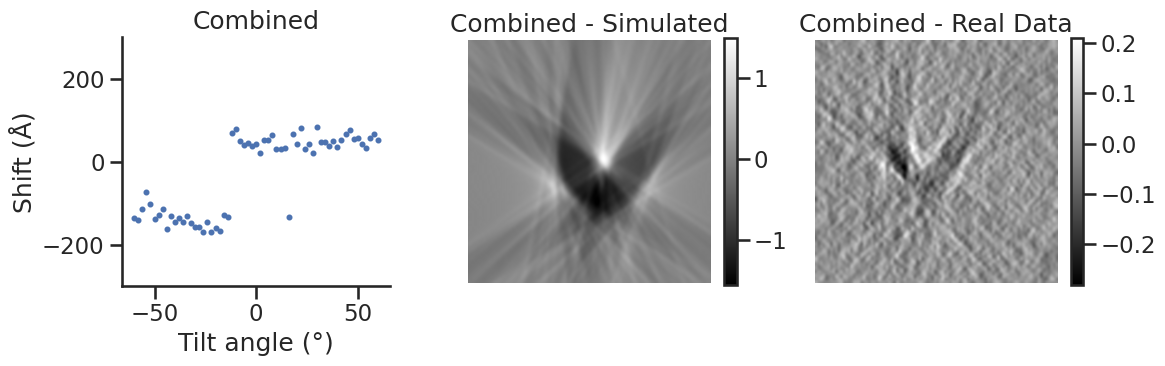

In [66]:
# Create side-by-side plots for each shift type using stored shifts
shift_types = ['Jitter', 'Trajectory', 'Outliers', 'Fractures']

# Get tilt angles for the stored shifts
tilt_angles_actual = tilt_series.angles.cpu().numpy()

for shift_type in shift_types:
    # Create figure with three subplots
    fig, (ax_shift, ax_recon_sim, ax_recon_real) = plt.subplots(1, 3, figsize=(12, 4))
    
    # Left subplot: Shift pattern (use stored shifts)
    shifts_for_plot = shifts_dict[shift_type].cpu()[:, 1].numpy()
    ax_shift.scatter(tilt_angles_actual, shifts_for_plot, s=8)
    ax_shift.set_ylim(-300, 300)
    ax_shift.set_ylabel('Shift (Å)')
    ax_shift.set_xlabel('Tilt angle (°)')
    ax_shift.set_title(f'{shift_type}')
    sns.despine(ax=ax_shift)
    
    # Middle subplot: Reconstruction [1] (simulated sphere)
    recon_sim = reconstructions[shift_type][1]
    im_sim = ax_recon_sim.imshow(recon_sim.numpy(), cmap='gray', interpolation='spline36')
    ax_recon_sim.set_title(f'{shift_type} - Simulated')
    ax_recon_sim.axis('off')
    plt.colorbar(im_sim, ax=ax_recon_sim, fraction=0.046)
    
    # Right subplot: Reconstruction [0] (actual data)
    recon_real = reconstructions[shift_type][0]
    im_real = ax_recon_real.imshow(recon_real.numpy(), cmap='gray', interpolation='spline36')
    ax_recon_real.set_title(f'{shift_type} - Real Data')
    ax_recon_real.axis('off')
    plt.colorbar(im_real, ax=ax_recon_real, fraction=0.046)
    
    fig.tight_layout()
    plt.savefig(f'shift_illustration_{shift_type.lower()}.svg', bbox_inches='tight', transparent=True)
    plt.show()

# Plot for the no-shift baseline
fig, (ax_shift, ax_recon_sim, ax_recon_real) = plt.subplots(1, 3, figsize=(12, 4))

# Left subplot: No shifts (flat line at 0)
ax_shift.scatter(tilt_angles_actual, np.zeros(len(tilt_angles_actual)), s=8)
ax_shift.set_ylim(-300, 300)
ax_shift.set_ylabel('Shift (Å)')
ax_shift.set_xlabel('Tilt angle (°)')
ax_shift.set_title('No Shifts')
sns.despine(ax=ax_shift)

# Middle subplot: Reconstruction [1] (simulated sphere)
recon_sim = reconstructions['No shifts'][1]
im_sim = ax_recon_sim.imshow(recon_sim.numpy(), cmap='gray', interpolation='spline36')
ax_recon_sim.set_title('No Shifts - Simulated')
ax_recon_sim.axis('off')
plt.colorbar(im_sim, ax=ax_recon_sim, fraction=0.046)

# Right subplot: Reconstruction [0] (actual data)
recon_real = reconstructions['No shifts'][0]
im_real = ax_recon_real.imshow(recon_real.numpy(), cmap='gray', interpolation='spline36')
ax_recon_real.set_title('No Shifts - Real Data')
ax_recon_real.axis('off')
plt.colorbar(im_real, ax=ax_recon_real, fraction=0.046)

fig.tight_layout()
plt.savefig('shift_illustration_no_shifts.svg', bbox_inches='tight', transparent=True)
plt.show()

# Plot for the combined shifts
fig, (ax_shift, ax_recon_sim, ax_recon_real) = plt.subplots(1, 3, figsize=(12, 4))

# Left subplot: Combined shift pattern (sum of all shifts)
combined_shifts_for_plot = shifts_dict['Combined'].cpu()[:, 1].numpy()
ax_shift.scatter(tilt_angles_actual, combined_shifts_for_plot, s=8)
ax_shift.set_ylim(-300, 300)  # Increased range for combined shifts
ax_shift.set_ylabel('Shift (Å)')
ax_shift.set_xlabel('Tilt angle (°)')
ax_shift.set_title('Combined')
sns.despine(ax=ax_shift)

# Middle subplot: Reconstruction [1] (simulated sphere)
recon_sim = reconstructions['Combined'][1]
im_sim = ax_recon_sim.imshow(recon_sim.numpy(), cmap='gray', interpolation='spline36')
ax_recon_sim.set_title('Combined - Simulated')
ax_recon_sim.axis('off')
plt.colorbar(im_sim, ax=ax_recon_sim, fraction=0.046)

# Right subplot: Reconstruction [0] (actual data)
recon_real = reconstructions['Combined'][0]
im_real = ax_recon_real.imshow(recon_real.numpy(), cmap='gray', interpolation='spline36')
ax_recon_real.set_title('Combined - Real Data')
ax_recon_real.axis('off')
plt.colorbar(im_real, ax=ax_recon_real, fraction=0.046)

fig.tight_layout()
plt.savefig('shift_illustration_combined.svg', bbox_inches='tight', transparent=True)
plt.show()